In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [8]:
import os
from dotenv import load_dotenv
load_dotenv()
# %env
os.chdir(os.environ.get("DATASET_PATH"))

In [9]:
placement = pd.read_csv("placement.csv")
placement.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [12]:
df = placement.copy()
placement.isnull().sum()

cgpa       0
package    0
dtype: int64

`linear regression `  
**Assumptions**

- linear relationship between inputs and output
- no multicollinearity
- normality of residuals
- homoscedasticity --> same scatter through out the axis
- no autocorrelation --> no pattern in residuals distribution


<Axes: xlabel='cgpa', ylabel='package'>

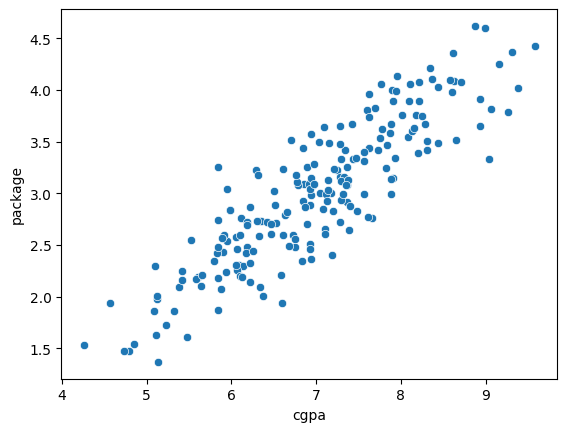

In [13]:
# lin relationship   --> has linear relation  -->  data has linear relationship -- so we can use linear regression
sns.scatterplot(data=df , x= 'cgpa', y='package')

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X , y = df.drop(columns=['package']) , df['package']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state= 1)

X_train.shape  , X_test.shape

((160, 1), (40, 1))

In [21]:
lr = LinearRegression()
lr.fit(X_train , y_train)

np.float64(-1.0859839580358042)

In [23]:
y_pred = lr.predict(X_test)

<Axes: xlabel='package', ylabel='Density'>

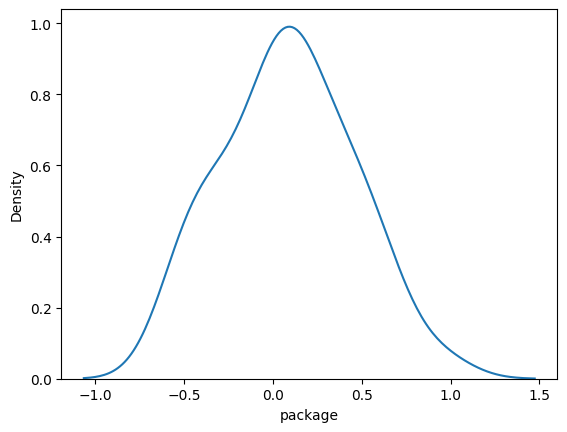

In [27]:
# check residuals 
residuals = y_test - y_pred 

sns.kdeplot(data=residuals)  # shows normal distribution means regression model fits the data

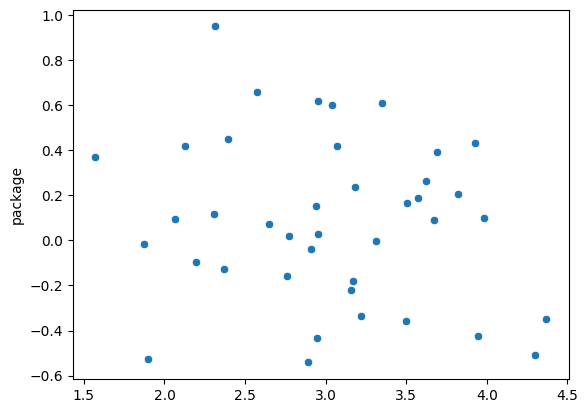

In [36]:
# check homoscedasticity -- > same scatter through out the axis 

sns.scatterplot(x= y_pred , y= residuals)
plt.show()

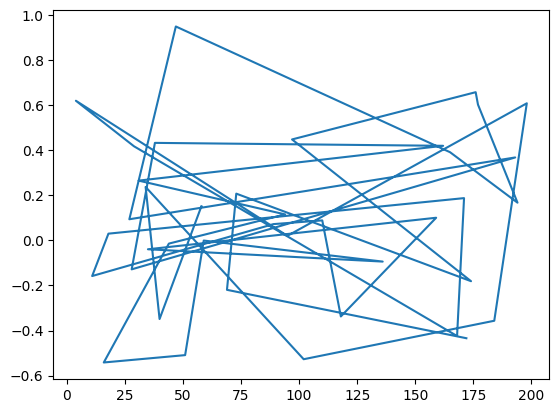

In [40]:
# there is no autocorrelation  --> no pattern

plt.plot(residuals)